<style>
.jp-RenderedMarkdown, .rendered_html { font-family: Arial, Helvetica, sans-serif; font-size: 15px; line-height: 1.55; }
.jp-RenderedMarkdown h1, .rendered_html h1 { font-size: 24px; font-weight: 700; }
.jp-RenderedMarkdown h2, .rendered_html h2 { font-size: 20px; font-weight: 650; }
.jp-RenderedMarkdown h3, .rendered_html h3 { font-size: 17px; font-weight: 600; }
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li, .rendered_html p, .rendered_html li { font-size: 15px; }
.jp-RenderedMarkdown code, .rendered_html code { font-size: 13px; }
</style>


# MeridianAI — Sales Forecasting

## Business Objective

Accurate sales forecasting enables retail businesses to anticipate future demand, optimize inventory levels, improve procurement planning, and reduce stock-related costs.

The objective of this notebook is to analyze historical retail sales data and develop forecasting models capable of predicting future monthly sales.

The notebook combines traditional statistical forecasting techniques with modern machine learning algorithms to identify the most accurate forecasting approach.

### Objectives

- Analyze historical monthly sales trends
- Identify seasonality and growth patterns
- Develop baseline and statistical forecasting models
- Build machine learning forecasting models
- Compare forecasting performance across multiple algorithms
- Select the best-performing model
- Generate business insights for inventory and demand planning

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import joblib

plt.style.use("default")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns",None)

In [2]:


df = pd.read_csv("../data/raw/online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


#  Dataset Overview

Before forecasting, the dataset is explored to understand its structure, data types, missing values, and overall quality.

This ensures that the forecasting models are trained on reliable and consistent data.

In [3]:
print(df.shape)

(1067371, 8)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.938898,172.705794,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0
Customer ID,824364.0,15324.638504,1697.464450,12346.00,13975.00,15255.0,16797.00,18287.0


In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(34335)

#  Data Cleaning

Forecasting models require clean chronological sales data.

The following preprocessing steps are applied:

- Convert dates
- Remove cancelled invoices
- Remove missing customer IDs
- Remove negative quantity
- Remove invalid prices
- Create Sales column

In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
df = df.dropna(subset=["Customer ID"])

In [10]:
df = df[
    ~df["Invoice"].astype(str).str.startswith("C")
]

In [11]:
df = df[df["Quantity"] > 0]

In [12]:
df = df[df["Price"] > 0]

In [13]:
df["Sales"] = (
    df["Quantity"] *
    df["Price"]
)

In [14]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


#  Monthly Sales Aggregation

Individual transactions are aggregated into monthly sales revenue.

This transforms transaction-level data into a time series suitable for forecasting.

In [15]:
monthly_sales = (

    df

    .set_index("InvoiceDate")

    .resample("ME")["Sales"]

    .sum()

    .reset_index()

)

In [16]:
monthly_sales.head()

,InvoiceDate,Sales
0,2009-12-31,686654.160
1,2010-01-31,557319.062
2,2010-02-28,506371.066
3,2010-03-31,699608.991
4,2010-04-30,594609.192


In [17]:
monthly_sales.tail()

,InvoiceDate,Sales
20,2011-08-31,645343.900
21,2011-09-30,952838.382
22,2011-10-31,1039318.790
23,2011-11-30,1161817.380
24,2011-12-31,518210.790


In [18]:
print(
    "Number of Months:",
    len(monthly_sales)
)

Number of Months: 25


In [19]:
monthly_sales["Year"] = (
    monthly_sales["InvoiceDate"].dt.year
)

monthly_sales["Month"] = (
    monthly_sales["InvoiceDate"].dt.month
)

monthly_sales["Quarter"] = (
    monthly_sales["InvoiceDate"].dt.quarter
)

monthly_sales["MonthName"] = (
    monthly_sales["InvoiceDate"].dt.month_name()
)

In [20]:
monthly_sales.head()

,InvoiceDate,Sales,Year,Month,Quarter,MonthName
0,2009-12-31,686654.160,2009,12,4,December
1,2010-01-31,557319.062,2010,1,1,January
2,2010-02-28,506371.066,2010,2,1,February
3,2010-03-31,699608.991,2010,3,1,March
4,2010-04-30,594609.192,2010,4,2,April


#  Exploratory Time-Series Analysis

Exploratory analysis helps identify trends, seasonality, growth patterns, and anomalies in historical sales data before forecasting models are developed.

Understanding these patterns improves feature engineering and model selection.

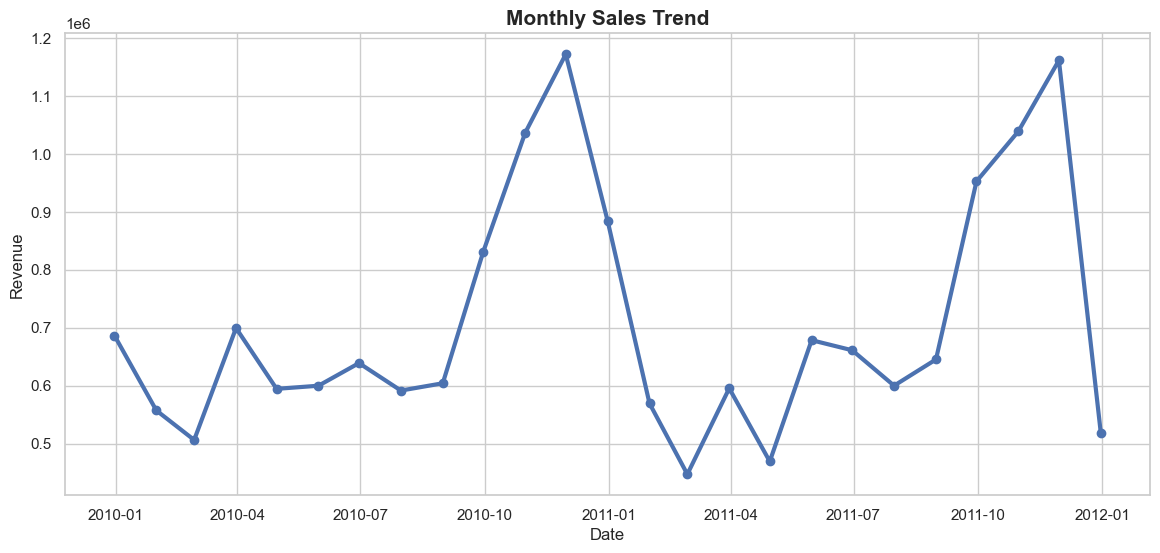

In [21]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["InvoiceDate"],
    monthly_sales["Sales"],
    linewidth=3,
    marker="o"
)

plt.title("Monthly Sales Trend", fontsize=15, weight="bold")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Business Insight

The monthly sales trend provides an overview of revenue fluctuations over time.

A generally increasing trend indicates business growth, whereas sharp peaks or drops may correspond to seasonal demand, promotional campaigns, or external market events.

In [22]:
monthly_sales["GrowthRate"] = (
    monthly_sales["Sales"]
    .pct_change()
    *100
)

monthly_sales.head()

,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate
0,2009-12-31,686654.160,2009,12,4,December,NaN
1,2010-01-31,557319.062,2010,1,1,January,-18.835552
2,2010-02-28,506371.066,2010,2,1,February,-9.141621
3,2010-03-31,699608.991,2010,3,1,March,38.161328
4,2010-04-30,594609.192,2010,4,2,April,-15.008355


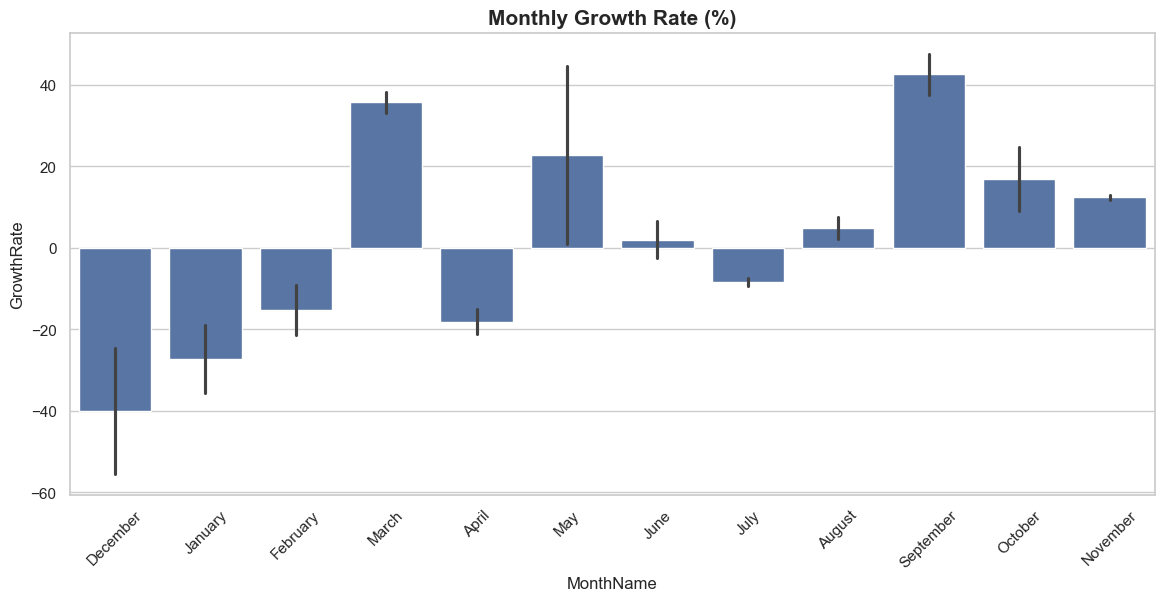

In [23]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=monthly_sales,
    x="MonthName",
    y="GrowthRate"
)

plt.title("Monthly Growth Rate (%)", fontsize=15, weight="bold")

plt.xticks(rotation=45)

plt.show()

### Business Insight

Growth rate measures the percentage increase or decrease in revenue compared to the previous month.

Positive values indicate sales expansion, while negative values highlight periods of declining demand.

In [24]:
yearly_sales = (

    monthly_sales

    .groupby("Year")["Sales"]

    .sum()

)

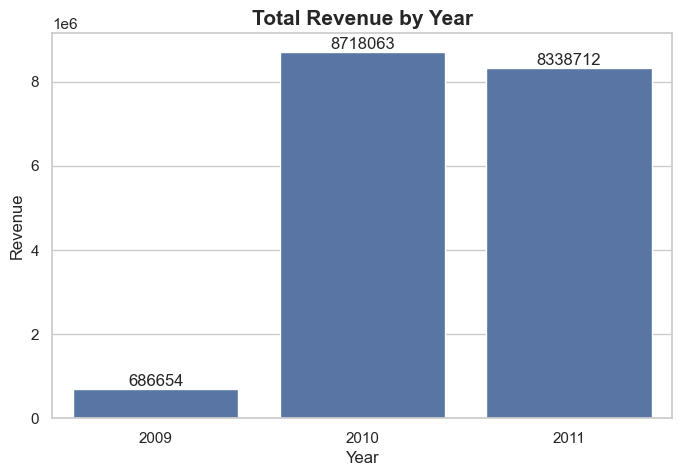

In [25]:
plt.figure(figsize=(8,5))

ax = sns.barplot(

    x=yearly_sales.index.astype(str),

    y=yearly_sales.values

)

plt.title(
    "Total Revenue by Year",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Revenue")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

### Business Insight

Yearly revenue summarizes overall business performance across different years and helps identify long-term growth.

In [26]:
month_order = [

    "January","February","March","April",

    "May","June","July","August",

    "September","October","November","December"

]

monthly_summary = (

    monthly_sales

    .groupby("MonthName")["Sales"]

    .mean()

    .reindex(month_order)

)

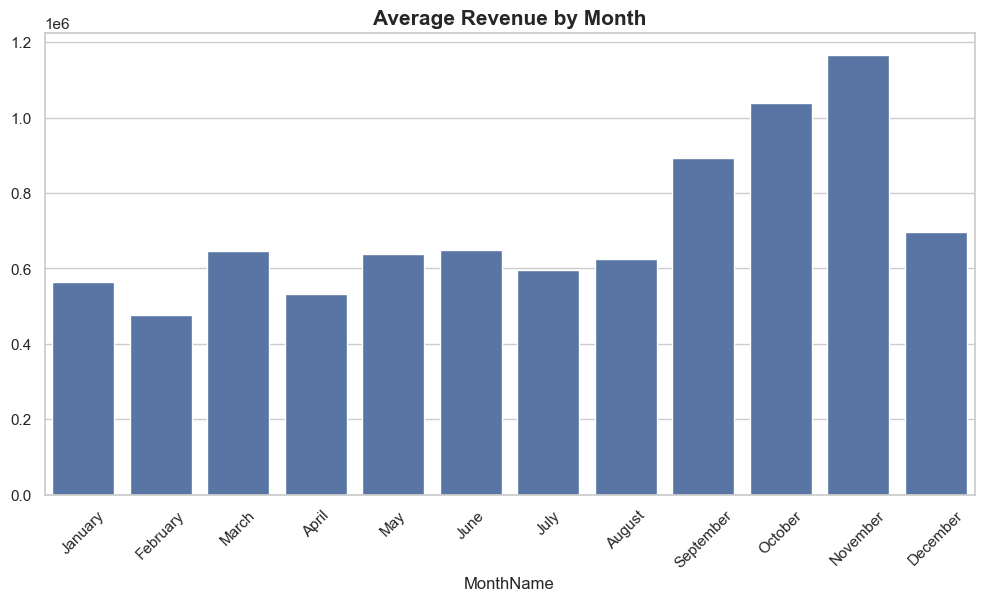

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(

    x=monthly_summary.index,

    y=monthly_summary.values

)

plt.xticks(rotation=45)

plt.title(
    "Average Revenue by Month",
    fontsize=15,
    weight="bold"
)

plt.show()

### Business Insight

Average monthly revenue helps identify seasonal purchasing behaviour and periods of consistently high or low demand.

In [28]:
monthly_sales["RollingMean_3"] = (

    monthly_sales["Sales"]

    .rolling(3)

    .mean()

)

monthly_sales["RollingStd_3"] = (

    monthly_sales["Sales"]

    .rolling(3)

    .std()

)

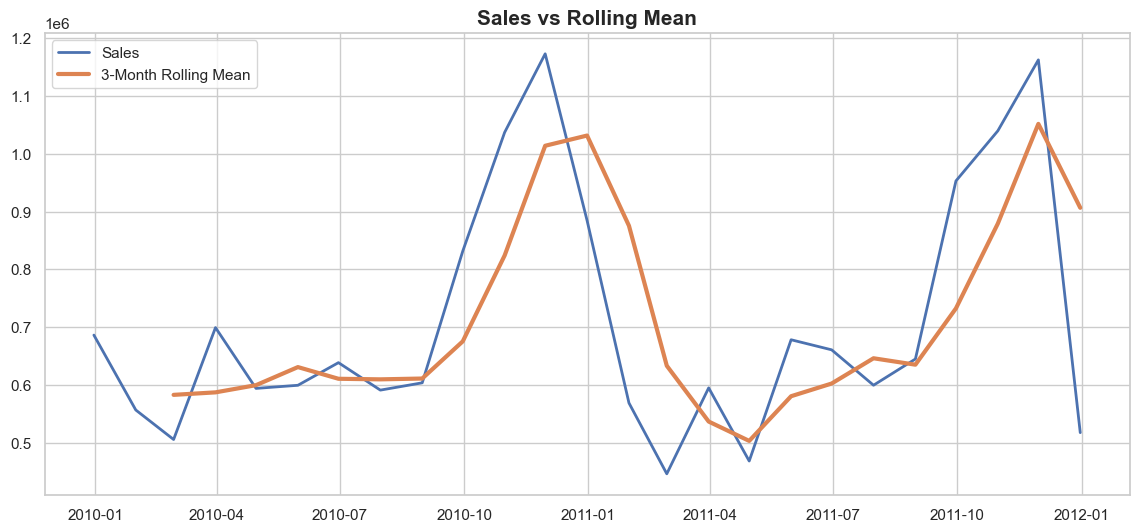

In [29]:
plt.figure(figsize=(14,6))

plt.plot(

    monthly_sales["InvoiceDate"],

    monthly_sales["Sales"],

    label="Sales",

    linewidth=2

)

plt.plot(

    monthly_sales["InvoiceDate"],

    monthly_sales["RollingMean_3"],

    label="3-Month Rolling Mean",

    linewidth=3

)

plt.legend()

plt.title("Sales vs Rolling Mean", fontsize=15, weight="bold")

plt.show()

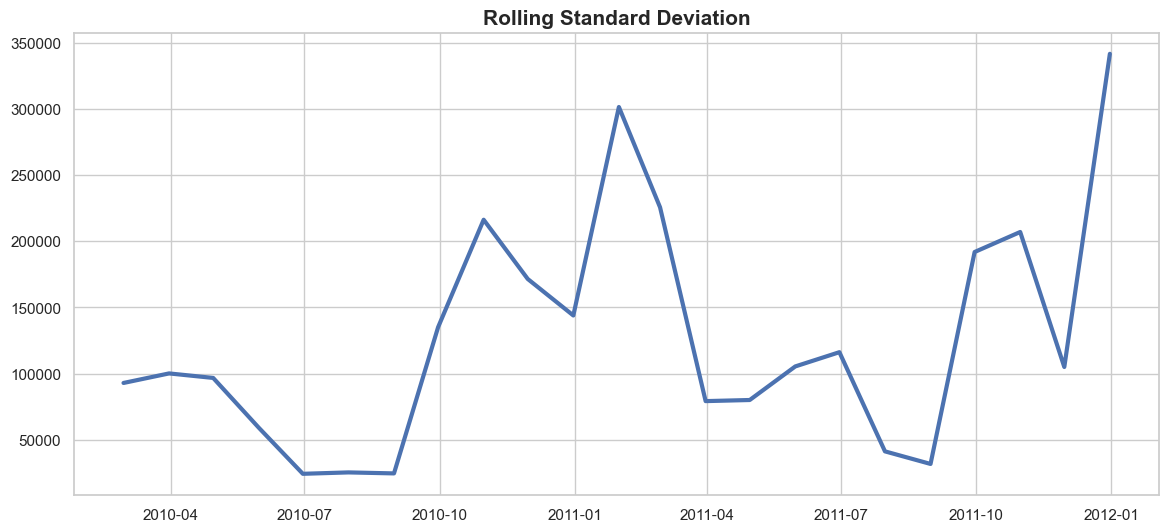

In [30]:
plt.figure(figsize=(14,6))

plt.plot(

    monthly_sales["InvoiceDate"],

    monthly_sales["RollingStd_3"],

    linewidth=3

)

plt.title(
    "Rolling Standard Deviation",
    fontsize=15,
    weight="bold"
)

plt.show()

### Business Insight

Rolling statistics smooth short-term fluctuations and help identify long-term trends and changes in sales volatility.

# ️ Time-Series Feature Engineering

Forecasting models cannot directly understand time.

Feature engineering transforms historical sales data into informative variables that capture temporal dependencies, trends, and seasonality.

In [31]:
monthly_sales["Lag_1"] = monthly_sales["Sales"].shift(1)

monthly_sales["Lag_2"] = monthly_sales["Sales"].shift(2)

monthly_sales["Lag_3"] = monthly_sales["Sales"].shift(3)

monthly_sales["Lag_6"] = monthly_sales["Sales"].shift(6)

monthly_sales.head()

,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate,RollingMean_3,RollingStd_3,Lag_1,Lag_2,Lag_3,Lag_6
0,2009-12-31,686654.160,2009,12,4,December,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-31,557319.062,2010,1,1,January,-18.835552,NaN,NaN,686654.160,NaN,NaN,NaN
2,2010-02-28,506371.066,2010,2,1,February,-9.141621,583448.096000,92938.384475,557319.062,686654.160,NaN,NaN
3,2010-03-31,699608.991,2010,3,1,March,38.161328,587766.373000,100152.398748,506371.066,557319.062,686654.160,NaN
4,2010-04-30,594609.192,2010,4,2,April,-15.008355,600196.416333,96740.047144,699608.991,506371.066,557319.062,NaN


### Why Lag Features?

Lag variables represent previous observations of the sales series.

For example, Lag_1 stores last month's sales, while Lag_6 stores sales six months earlier. These features help machine learning algorithms learn temporal relationships.

In [32]:
monthly_sales["RollingMean_6"] = (

    monthly_sales["Sales"]

    .rolling(6)

    .mean()

)

monthly_sales["RollingMean_12"] = (

    monthly_sales["Sales"]

    .rolling(12)

    .mean()

)

monthly_sales.head()

,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate,RollingMean_3,RollingStd_3,Lag_1,Lag_2,Lag_3,Lag_6,RollingMean_6,RollingMean_12
0,2009-12-31,686654.160,2009,12,4,December,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-31,557319.062,2010,1,1,January,-18.835552,NaN,NaN,686654.160,NaN,NaN,NaN,NaN,NaN
2,2010-02-28,506371.066,2010,2,1,February,-9.141621,583448.096000,92938.384475,557319.062,686654.160,NaN,NaN,NaN,NaN
3,2010-03-31,699608.991,2010,3,1,March,38.161328,587766.373000,100152.398748,506371.066,557319.062,686654.160,NaN,NaN,NaN
4,2010-04-30,594609.192,2010,4,2,April,-15.008355,600196.416333,96740.047144,699608.991,506371.066,557319.062,NaN,NaN,NaN


### Why Rolling Features?

Rolling averages smooth short-term fluctuations while highlighting long-term trends. They provide additional contextual information for forecasting models.

In [33]:
monthly_sales["Day"] = monthly_sales["InvoiceDate"].dt.day

monthly_sales["Weekday"] = monthly_sales["InvoiceDate"].dt.weekday

monthly_sales["Weekend"] = (

    monthly_sales["Weekday"]

    >=5

).astype(int)

monthly_sales.head()

,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate,RollingMean_3,RollingStd_3,Lag_1,Lag_2,Lag_3,Lag_6,RollingMean_6,RollingMean_12,Day,Weekday,Weekend
0,2009-12-31,686654.160,2009,12,4,December,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,3,0
1,2010-01-31,557319.062,2010,1,1,January,-18.835552,NaN,NaN,686654.160,NaN,NaN,NaN,NaN,NaN,31,6,1
2,2010-02-28,506371.066,2010,2,1,February,-9.141621,583448.096000,92938.384475,557319.062,686654.160,NaN,NaN,NaN,NaN,28,6,1
3,2010-03-31,699608.991,2010,3,1,March,38.161328,587766.373000,100152.398748,506371.066,557319.062,686654.160,NaN,NaN,NaN,31,2,0
4,2010-04-30,594609.192,2010,4,2,April,-15.008355,600196.416333,96740.047144,699608.991,506371.066,557319.062,NaN,NaN,NaN,30,4,0


### Why Calendar Features?

Calendar variables allow forecasting models to identify recurring seasonal patterns such as monthly, weekly, or holiday-related sales behaviour.

In [34]:
print(monthly_sales.isna().sum())

InvoiceDate        0
Sales              0
Year               0
Month              0
Quarter            0
MonthName          0
GrowthRate         1
RollingMean_3      2
RollingStd_3       2
Lag_1              1
Lag_2              2
Lag_3              3
Lag_6              6
RollingMean_6      5
RollingMean_12    11
Day                0
Weekday            0
Weekend            0
dtype: int64


In [35]:
forecast_df = monthly_sales.dropna().reset_index(drop=True)

print("Rows after feature engineering :", len(forecast_df))

forecast_df.head()

Rows after feature engineering : 14


,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate,RollingMean_3,RollingStd_3,Lag_1,Lag_2,Lag_3,Lag_6,RollingMean_6,RollingMean_12,Day,Weekday,Weekend
0,2010-11-30,1172336.042,2010,11,4,November,13.085624,1.013544e+06,171534.759998,1036680.000,831615.001,604242.650,599985.790,812596.168833,710010.439500,30,1,0
1,2010-12-31,884591.890,2010,12,4,December,-24.544511,1.031203e+06,143950.252949,1172336.042,1036680.000,831615.001,639066.580,853517.053833,726505.250333,31,4,0
2,2011-01-31,569445.040,2011,1,1,January,-35.626242,8.754577e+05,301549.275787,884591.890,1172336.042,1036680.000,591636.740,849818.437167,727515.748500,31,0,0
3,2011-02-28,447137.350,2011,2,1,February,-21.478401,6.337248e+05,225700.089597,569445.040,884591.890,1172336.042,604242.650,823634.220500,722579.605500,28,0,0
4,2011-03-31,595500.760,2011,3,1,March,33.180724,5.373610e+05,79214.658791,447137.350,569445.040,884591.890,831615.001,784281.847000,713903.919583,31,3,0


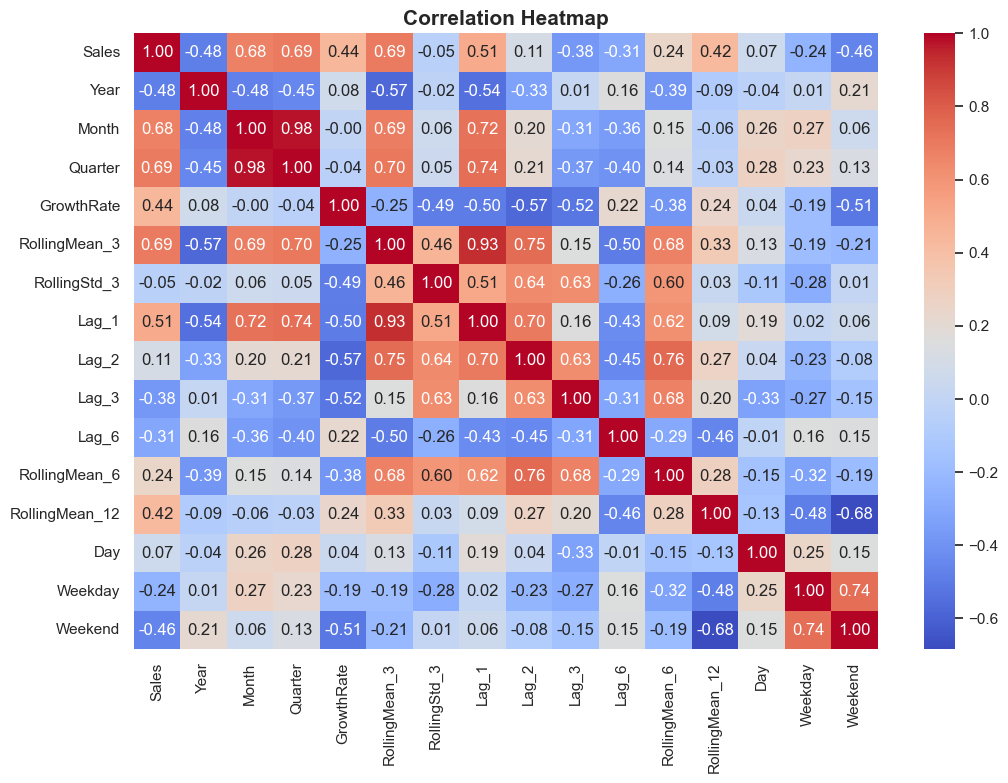

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(

    forecast_df.select_dtypes(include=np.number).corr(),

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Heatmap", fontsize=15, weight="bold")

plt.show()

## Business Insight

The correlation heatmap highlights relationships between engineered features and sales.

Highly correlated lag and rolling statistics indicate that previous sales values are strong predictors of future demand.

In [37]:
forecast_df.to_csv(

    "../data/processed/sales_forecast.csv",

    index=False

)

print("Forecast dataset saved successfully.")

forecast_df.head()

Forecast dataset saved successfully.


,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate,RollingMean_3,RollingStd_3,Lag_1,Lag_2,Lag_3,Lag_6,RollingMean_6,RollingMean_12,Day,Weekday,Weekend
0,2010-11-30,1172336.042,2010,11,4,November,13.085624,1.013544e+06,171534.759998,1036680.000,831615.001,604242.650,599985.790,812596.168833,710010.439500,30,1,0
1,2010-12-31,884591.890,2010,12,4,December,-24.544511,1.031203e+06,143950.252949,1172336.042,1036680.000,831615.001,639066.580,853517.053833,726505.250333,31,4,0
2,2011-01-31,569445.040,2011,1,1,January,-35.626242,8.754577e+05,301549.275787,884591.890,1172336.042,1036680.000,591636.740,849818.437167,727515.748500,31,0,0
3,2011-02-28,447137.350,2011,2,1,February,-21.478401,6.337248e+05,225700.089597,569445.040,884591.890,1172336.042,604242.650,823634.220500,722579.605500,28,0,0
4,2011-03-31,595500.760,2011,3,1,March,33.180724,5.373610e+05,79214.658791,447137.350,569445.040,884591.890,831615.001,784281.847000,713903.919583,31,3,0


In [38]:
# Machine Learning Dataset

ml_df = forecast_df.copy()

print("Rows :", len(ml_df))

ml_df.head()

Rows : 14


,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate,RollingMean_3,RollingStd_3,Lag_1,Lag_2,Lag_3,Lag_6,RollingMean_6,RollingMean_12,Day,Weekday,Weekend
0,2010-11-30,1172336.042,2010,11,4,November,13.085624,1.013544e+06,171534.759998,1036680.000,831615.001,604242.650,599985.790,812596.168833,710010.439500,30,1,0
1,2010-12-31,884591.890,2010,12,4,December,-24.544511,1.031203e+06,143950.252949,1172336.042,1036680.000,831615.001,639066.580,853517.053833,726505.250333,31,4,0
2,2011-01-31,569445.040,2011,1,1,January,-35.626242,8.754577e+05,301549.275787,884591.890,1172336.042,1036680.000,591636.740,849818.437167,727515.748500,31,0,0
3,2011-02-28,447137.350,2011,2,1,February,-21.478401,6.337248e+05,225700.089597,569445.040,884591.890,1172336.042,604242.650,823634.220500,722579.605500,28,0,0
4,2011-03-31,595500.760,2011,3,1,March,33.180724,5.373610e+05,79214.658791,447137.350,569445.040,884591.890,831615.001,784281.847000,713903.919583,31,3,0


#  Statistical Forecasting

Statistical forecasting methods establish a performance baseline before more advanced machine learning models are introduced.

The following approaches are implemented:

- Naive Forecast
- ARIMA

In [39]:
split_index = int(len(forecast_df) * 0.8)

train = forecast_df.iloc[:split_index]

test = forecast_df.iloc[split_index:]

print("Training Months :", len(train))
print("Testing Months :", len(test))

Training Months : 11
Testing Months : 3


In [40]:
naive_predictions = []

last_value = train["Sales"].iloc[-1]

for _ in range(len(test)):
    naive_predictions.append(last_value)

In [41]:
naive_mae = mean_absolute_error(

    test["Sales"],

    naive_predictions

)

naive_rmse = np.sqrt(

    mean_squared_error(

        test["Sales"],

        naive_predictions

    )

)

print("MAE :", naive_mae)

print("RMSE:", naive_rmse)

MAE : 243362.3326666667
RMSE: 282873.4854433745


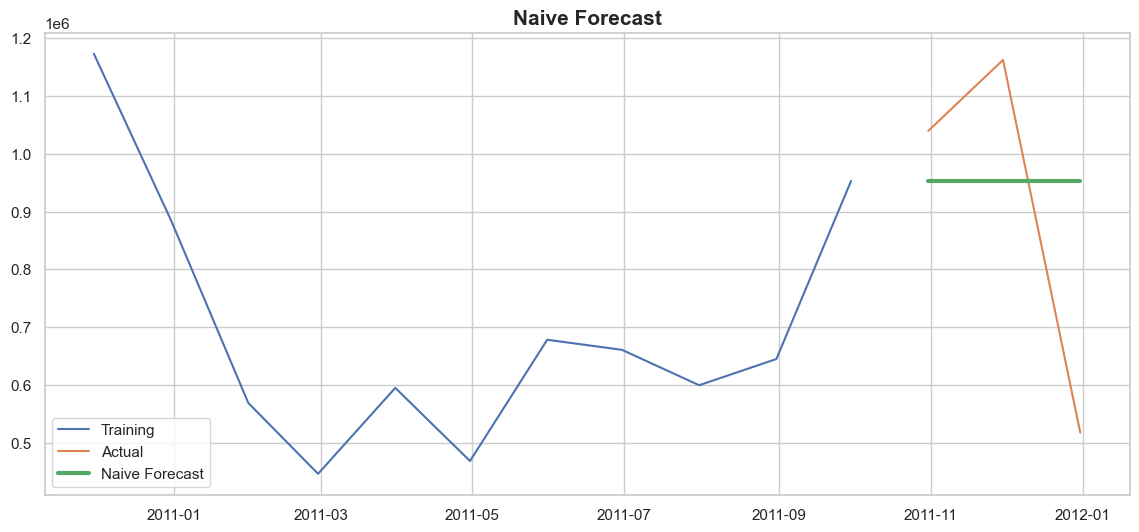

In [42]:
plt.figure(figsize=(14,6))

plt.plot(

    train["InvoiceDate"],

    train["Sales"],

    label="Training"

)

plt.plot(

    test["InvoiceDate"],

    test["Sales"],

    label="Actual"

)

plt.plot(

    test["InvoiceDate"],

    naive_predictions,

    label="Naive Forecast",

    linewidth=3

)

plt.legend()

plt.title(

    "Naive Forecast",

    fontsize=15,

    weight="bold"

)

plt.show()


### Business Insight

The Naive Forecast assumes that future sales remain equal to the most recent observed value.

Although simple, it serves as an important baseline. Any advanced forecasting model should outperform this approach.

#  ARIMA Forecasting

ARIMA (AutoRegressive Integrated Moving Average) captures trends and temporal dependencies in historical sales data.

It is widely used as a benchmark forecasting technique for time-series problems.

In [43]:
adf_result = adfuller(

    forecast_df["Sales"]

)

print("ADF Statistic :", adf_result[0])

print("p-value :", adf_result[1])


ADF Statistic : -2.4885700388925884
p-value : 0.11828018441113813


In [44]:
if adf_result[1] < 0.05:

    print("Series is Stationary")

else:

    print("Series is NOT Stationary")

Series is NOT Stationary


In [45]:
arima_model = ARIMA(

    train["Sales"],

    order=(1,1,1)

)

arima_fit = arima_model.fit()

c:\Users\Garvit\Desktop\RetailAI Nexus\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Garvit\Desktop\RetailAI Nexus\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [46]:
arima_predictions = arima_fit.forecast(

    steps=len(test)

)

In [47]:
arima_mae = mean_absolute_error(

    test["Sales"],

    arima_predictions

)

arima_rmse = np.sqrt(

    mean_squared_error(

        test["Sales"],

        arima_predictions

    )

)

print("MAE :", arima_mae)

print("RMSE:", arima_rmse)

MAE : 287770.44935627934
RMSE: 302472.60854582454


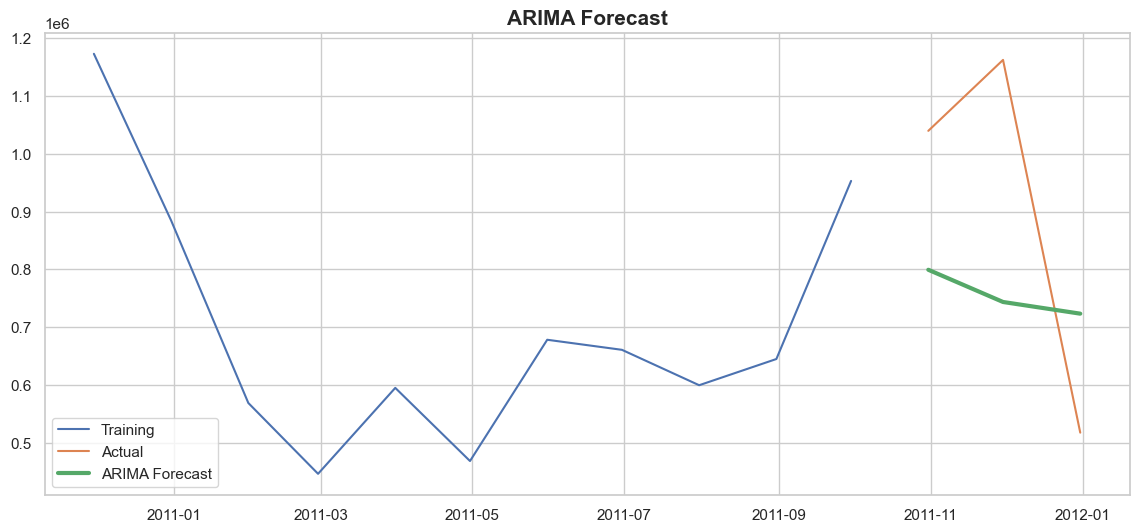

In [48]:
plt.figure(figsize=(14,6))

plt.plot(

    train["InvoiceDate"],

    train["Sales"],

    label="Training"

)

plt.plot(

    test["InvoiceDate"],

    test["Sales"],

    label="Actual"

)

plt.plot(

    test["InvoiceDate"],

    arima_predictions,

    label="ARIMA Forecast",

    linewidth=3

)

plt.legend()

plt.title(

    "ARIMA Forecast",

    fontsize=15,

    weight="bold"

)

plt.show()

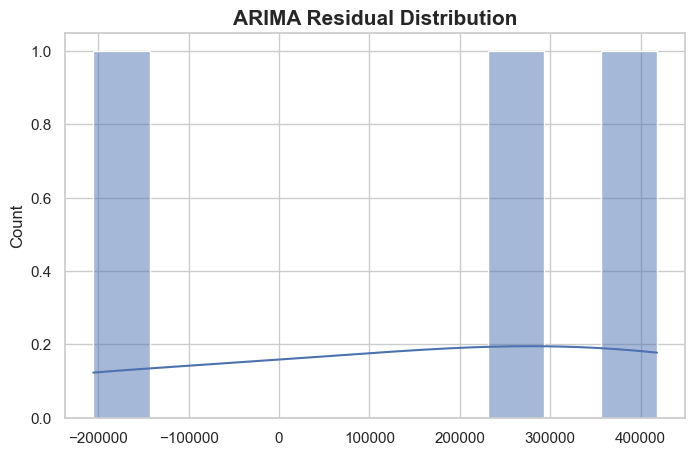

In [49]:
residuals = test["Sales"] - arima_predictions

plt.figure(figsize=(8,5))

sns.histplot(

    residuals,

    kde=True,

    bins=10

)

plt.title(

    "ARIMA Residual Distribution",

    fontsize=15,

    weight="bold"

)

plt.show()


### Business Insight

ARIMA models temporal dependencies in sales and generally provides more reliable forecasts than the Naive approach.

Its performance establishes a statistical benchmark before introducing machine learning forecasting models.

#  Preparing Forecasting Datasets

To maintain a clean forecasting workflow, separate datasets are created for statistical forecasting and machine learning models.

This prevents feature engineering performed for machine learning algorithms from affecting traditional time-series forecasting methods.

In [50]:
# Statistical Forecasting Dataset

statistical_df = monthly_sales.copy()

print("Rows :", len(statistical_df))

statistical_df.head()

Rows : 25


,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate,RollingMean_3,RollingStd_3,Lag_1,Lag_2,Lag_3,Lag_6,RollingMean_6,RollingMean_12,Day,Weekday,Weekend
0,2009-12-31,686654.160,2009,12,4,December,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,3,0
1,2010-01-31,557319.062,2010,1,1,January,-18.835552,NaN,NaN,686654.160,NaN,NaN,NaN,NaN,NaN,31,6,1
2,2010-02-28,506371.066,2010,2,1,February,-9.141621,583448.096000,92938.384475,557319.062,686654.160,NaN,NaN,NaN,NaN,28,6,1
3,2010-03-31,699608.991,2010,3,1,March,38.161328,587766.373000,100152.398748,506371.066,557319.062,686654.160,NaN,NaN,NaN,31,2,0
4,2010-04-30,594609.192,2010,4,2,April,-15.008355,600196.416333,96740.047144,699608.991,506371.066,557319.062,NaN,NaN,NaN,30,4,0


In [51]:
# Machine Learning Dataset

ml_df = monthly_sales.copy()

print("Rows :", len(ml_df))

ml_df.head()

Rows : 25


,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate,RollingMean_3,RollingStd_3,Lag_1,Lag_2,Lag_3,Lag_6,RollingMean_6,RollingMean_12,Day,Weekday,Weekend
0,2009-12-31,686654.160,2009,12,4,December,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,3,0
1,2010-01-31,557319.062,2010,1,1,January,-18.835552,NaN,NaN,686654.160,NaN,NaN,NaN,NaN,NaN,31,6,1
2,2010-02-28,506371.066,2010,2,1,February,-9.141621,583448.096000,92938.384475,557319.062,686654.160,NaN,NaN,NaN,NaN,28,6,1
3,2010-03-31,699608.991,2010,3,1,March,38.161328,587766.373000,100152.398748,506371.066,557319.062,686654.160,NaN,NaN,NaN,31,2,0
4,2010-04-30,594609.192,2010,4,2,April,-15.008355,600196.416333,96740.047144,699608.991,506371.066,557319.062,NaN,NaN,NaN,30,4,0


#  Machine Learning Feature Engineering

Machine learning models cannot directly learn temporal relationships.

Historical sales information is converted into lag variables and rolling statistics that capture recent trends and seasonality.

In [52]:
# Lag Features

ml_df["Lag_1"] = ml_df["Sales"].shift(1)

ml_df["Lag_2"] = ml_df["Sales"].shift(2)

ml_df["Lag_3"] = ml_df["Sales"].shift(3)

ml_df["Lag_6"] = ml_df["Sales"].shift(6)

In [53]:
# Rolling Features

ml_df["RollingMean_3"] = (

    ml_df["Sales"]

    .rolling(3)

    .mean()

)

ml_df["RollingStd_3"] = (

    ml_df["Sales"]

    .rolling(3)

    .std()

)

ml_df["RollingMean_6"] = (

    ml_df["Sales"]

    .rolling(6)

    .mean()

)

ml_df["RollingStd_6"] = (

    ml_df["Sales"]

    .rolling(6)

    .std()

)

In [54]:
# Calendar Features

ml_df["Day"] = ml_df["InvoiceDate"].dt.day

ml_df["Weekday"] = ml_df["InvoiceDate"].dt.weekday

ml_df["Weekend"] = (

    ml_df["Weekday"] >= 5

).astype(int)

In [55]:
print(ml_df.isna().sum())

InvoiceDate        0
Sales              0
Year               0
Month              0
Quarter            0
MonthName          0
GrowthRate         1
RollingMean_3      2
RollingStd_3       2
Lag_1              1
Lag_2              2
Lag_3              3
Lag_6              6
RollingMean_6      5
RollingMean_12    11
Day                0
Weekday            0
Weekend            0
RollingStd_6       5
dtype: int64


In [56]:
ml_df = ml_df.dropna().reset_index(drop=True)

print("Rows :", len(ml_df))

ml_df.head()

Rows : 14


,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate,RollingMean_3,RollingStd_3,Lag_1,Lag_2,Lag_3,Lag_6,RollingMean_6,RollingMean_12,Day,Weekday,Weekend,RollingStd_6
0,2010-11-30,1172336.042,2010,11,4,November,13.085624,1.013544e+06,171534.759998,1036680.000,831615.001,604242.650,599985.790,812596.168833,710010.439500,30,1,0,245900.317980
1,2010-12-31,884591.890,2010,12,4,December,-24.544511,1.031203e+06,143950.252949,1172336.042,1036680.000,831615.001,639066.580,853517.053833,726505.250333,31,4,0,231239.522835
2,2011-01-31,569445.040,2011,1,1,January,-35.626242,8.754577e+05,301549.275787,884591.890,1172336.042,1036680.000,591636.740,849818.437167,727515.748500,31,0,0,236386.173996
3,2011-02-28,447137.350,2011,2,1,February,-21.478401,6.337248e+05,225700.089597,569445.040,884591.890,1172336.042,604242.650,823634.220500,722579.605500,28,0,0,274635.404778
4,2011-03-31,595500.760,2011,3,1,March,33.180724,5.373610e+05,79214.658791,447137.350,569445.040,884591.890,831615.001,784281.847000,713903.919583,31,3,0,289762.853013


In [57]:
forecast_features = [
    "Year",
    "Month",
    "Quarter",
    "Day",
    "Weekday",
    "Weekend",
    "GrowthRate",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_6",
    "RollingMean_3",
    "RollingStd_3",
    "RollingMean_6",
    "RollingStd_6"
]

In [58]:
X = ml_df[forecast_features]

y = ml_df["Sales"]

In [59]:
split_index = int(

    len(ml_df) * 0.8

)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

print("Training :", len(X_train))

print("Testing :", len(X_test))

Training : 11
Testing : 3


#  Linear Regression Forecasting

Linear Regression is used as the first supervised learning model for forecasting monthly sales.

Unlike statistical forecasting methods, Linear Regression learns relationships between historical sales and engineered features such as lag variables, rolling statistics, growth rate and calendar information.

This model serves as a simple machine learning baseline before evaluating more advanced ensemble algorithms.

In [60]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [61]:
lr_model = LinearRegression()
lr_model.fit(
    X_train_scaled,
    y_train
)
lr_predictions = lr_model.predict(
    X_test_scaled
)
print(lr_predictions)

[1020416.34264479  870366.44565113  590537.77941514]


In [62]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_mse = mean_squared_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

MAE : 127560.12370640527
MSE : 30177381015.567646
RMSE: 173716.38096497304
R²  : 0.6124418764141657


In [63]:
comparison_lr = pd.DataFrame({

    "Month": ml_df.loc[y_test.index, "InvoiceDate"],

    "Actual Sales": y_test.values,

    "Predicted Sales": np.round(lr_predictions, 2)

})

comparison_lr["Error"] = (
    comparison_lr["Actual Sales"]
    - comparison_lr["Predicted Sales"]
)

comparison_lr["Absolute Error"] = (
    comparison_lr["Error"].abs()
)

comparison_lr

,Month,Actual Sales,Predicted Sales,Error,Absolute Error
11,2011-10-31,1039318.79,1020416.34,18902.45,18902.45
12,2011-11-30,1161817.38,870366.45,291450.93,291450.93
13,2011-12-31,518210.79,590537.78,-72326.99,72326.99


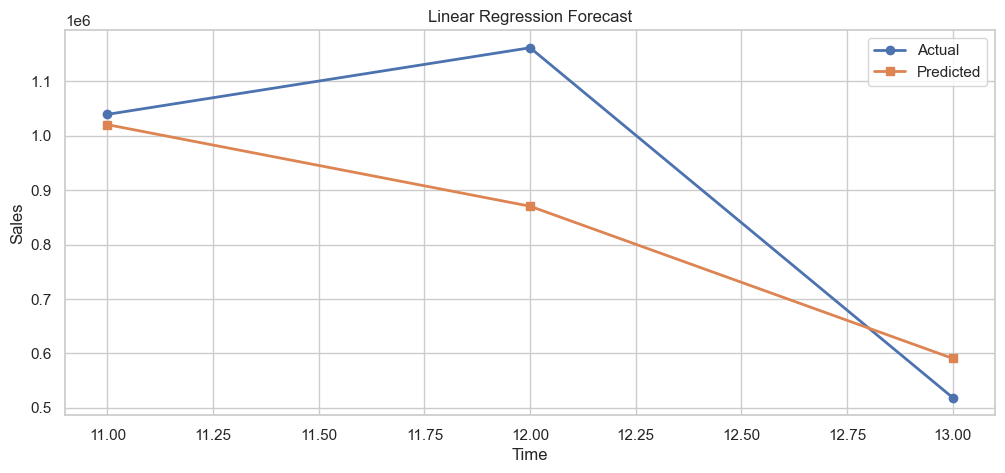

In [64]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    y_test.index,
    lr_predictions,
    marker="s",
    linewidth=2,
    label="Predicted"
)

plt.title("Linear Regression Forecast")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.grid(True)

plt.legend()

plt.show()

In [65]:
forecast_results = ml_df.copy()

forecast_results.loc[
    y_test.index,
    "LR_Prediction"
] = lr_predictions

forecast_results.tail()

,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate,RollingMean_3,RollingStd_3,Lag_1,Lag_2,Lag_3,Lag_6,RollingMean_6,RollingMean_12,Day,Weekday,Weekend,RollingStd_6,LR_Prediction
9,2011-08-31,645343.900,2011,8,3,August,7.541004,6.355495e+05,31716.599454,600091.011,661213.690,678594.560,447137.350,608324.047000,715979.133750,31,2,0,75754.007719,NaN
10,2011-09-30,952838.382,2011,9,3,September,47.648158,7.327578e+05,191933.750797,645343.900,600091.011,661213.690,595500.760,667880.317333,726081.082167,30,4,0,158705.603394,NaN
11,2011-10-31,1039318.790,2011,10,4,October,9.076084,8.791670e+05,207061.959881,952838.382,645343.900,600091.011,469200.361,762900.055500,726300.981333,31,0,0,184530.568104,1.020416e+06
12,2011-11-30,1161817.380,2011,11,4,November,11.786431,1.051325e+06,105005.545191,1039318.790,952838.382,645343.900,678594.560,843437.192167,725424.426167,30,2,0,238062.128758,8.703664e+05
13,2011-12-31,518210.790,2011,12,4,December,-55.396537,9.064490e+05,341757.441984,1161817.380,1039318.790,952838.382,661213.690,819603.375500,694892.667833,31,5,1,265528.299345,5.905378e+05


In [66]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coefficients

,Feature,Coefficient
6,GrowthRate,97076.464409
8,Lag_2,-84739.968288
9,Lag_3,-77845.521447
11,RollingMean_3,76268.261386
0,Year,-69515.495861
10,Lag_6,-66944.404758
7,Lag_1,62078.747936
12,RollingStd_3,54775.352154
5,Weekend,-15044.504186
2,Quarter,-13805.675517


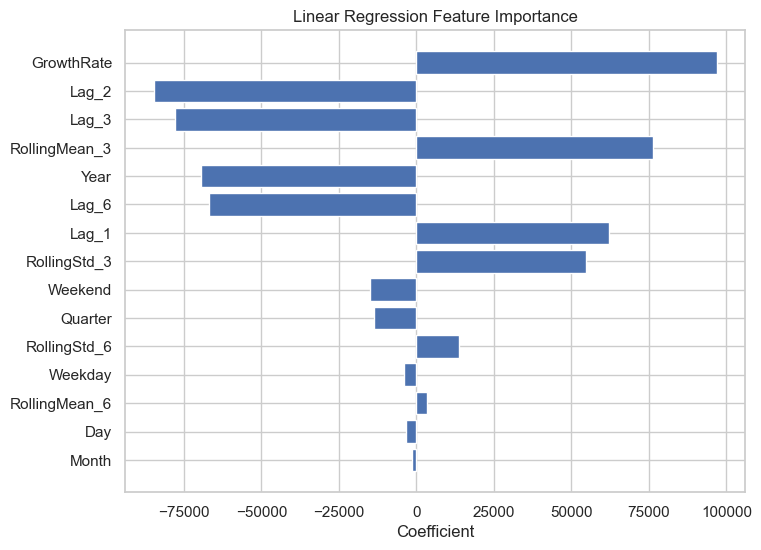

In [67]:
plt.figure(figsize=(8,6))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.title("Linear Regression Feature Importance")

plt.xlabel("Coefficient")

plt.gca().invert_yaxis()

plt.show()

In [68]:
joblib.dump(
    scaler,
    "../Models/forecast_scaler.pkl"
)

['../Models/forecast_scaler.pkl']

In [69]:
joblib.dump(
    forecast_features,
    "../Models/forecast_features.pkl"
)

print("Feature list saved successfully.")

Feature list saved successfully.


In [70]:
joblib.dump(
    lr_model,
    "../Models/linear_regression_forecasting.pkl"
)

print("Linear Regression model saved successfully.")

Linear Regression model saved successfully.


##  Linear Regression Insights

Linear Regression models the relationship between engineered time-series features and monthly sales using a linear equation.

The coefficient plot shows which lag, rolling and calendar features contribute most strongly to the prediction.

Although Linear Regression is simple and interpretable, it cannot capture highly nonlinear patterns present in retail sales. Therefore, more advanced ensemble models such as Random Forest and XGBoost will also be evaluated.

#  Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Unlike Linear Regression, Random Forest can capture nonlinear relationships and interactions between lag features, rolling statistics, growth rates, and calendar variables.

This model is expected to outperform Linear Regression for complex retail sales forecasting.

In [71]:
rf_model = RandomForestRegressor(

    n_estimators=300,

    max_depth=8,

    min_samples_split=4,

    min_samples_leaf=2,

    random_state=42

)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [72]:
rf_predictions = rf_model.predict(X_test)

In [73]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print(f"MAE  : {rf_mae:.2f}")
print(f"MSE  : {rf_mse:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

MAE  : 256212.62
MSE  : 72953819285.48
RMSE : 270099.65
R²   : 0.0631


In [74]:
rf_metrics = pd.DataFrame({

    "Metric": ["MAE", "MSE", "RMSE", "R²"],

    "Value": [
        rf_mae,
        rf_mse,
        rf_rmse,
        rf_r2
    ]

})

rf_metrics

,Metric,Value
0,MAE,2.562126e+05
1,MSE,7.295382e+10
2,RMSE,2.700996e+05
3,R²,6.307823e-02


In [75]:
comparison_rf = pd.DataFrame({

    "Month": ml_df.loc[y_test.index, "InvoiceDate"],

    "Actual Sales": y_test.values,

    "Predicted Sales": np.round(
        rf_predictions,
        2
    )

})

comparison_rf["Error"] = (

    comparison_rf["Actual Sales"]

    - comparison_rf["Predicted Sales"]

)

comparison_rf["Absolute Error"] = (

    comparison_rf["Error"]

    .abs()

)

comparison_rf

,Month,Actual Sales,Predicted Sales,Error,Absolute Error
11,2011-10-31,1039318.79,894226.99,145091.80,145091.80
12,2011-11-30,1161817.38,891305.66,270511.72,270511.72
13,2011-12-31,518210.79,871245.12,-353034.33,353034.33


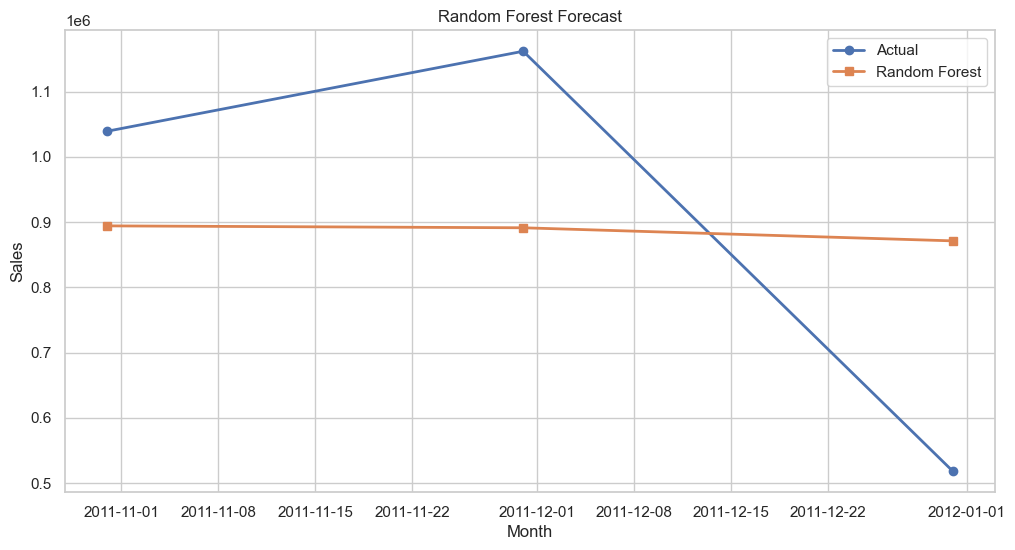

In [76]:
plt.figure(figsize=(12,6))

plt.plot(

    comparison_rf["Month"],

    comparison_rf["Actual Sales"],

    marker="o",

    linewidth=2,

    label="Actual"

)

plt.plot(

    comparison_rf["Month"],

    comparison_rf["Predicted Sales"],

    marker="s",

    linewidth=2,

    label="Random Forest"

)

plt.title("Random Forest Forecast")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

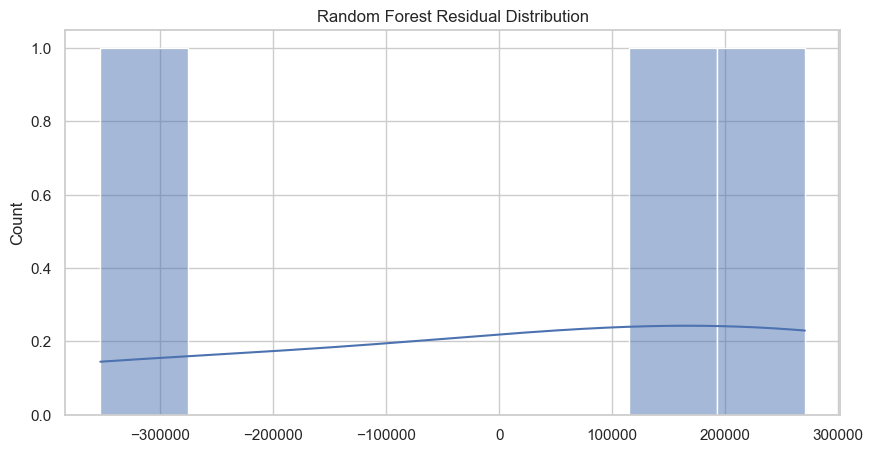

In [77]:
residuals_rf = (

    comparison_rf["Actual Sales"]

    - comparison_rf["Predicted Sales"]

)

plt.figure(figsize=(10,5))

sns.histplot(

    residuals_rf,

    kde=True,

    bins=8

)

plt.title("Random Forest Residual Distribution")

plt.show()

In [78]:
feature_importance = pd.DataFrame({

    "Feature": forecast_features,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance

,Feature,Importance
1,Month,0.473865
6,GrowthRate,0.111406
11,RollingMean_3,0.090320
2,Quarter,0.070056
0,Year,0.052407
14,RollingStd_6,0.051890
7,Lag_1,0.036285
3,Day,0.033047
12,RollingStd_3,0.029242
10,Lag_6,0.013407


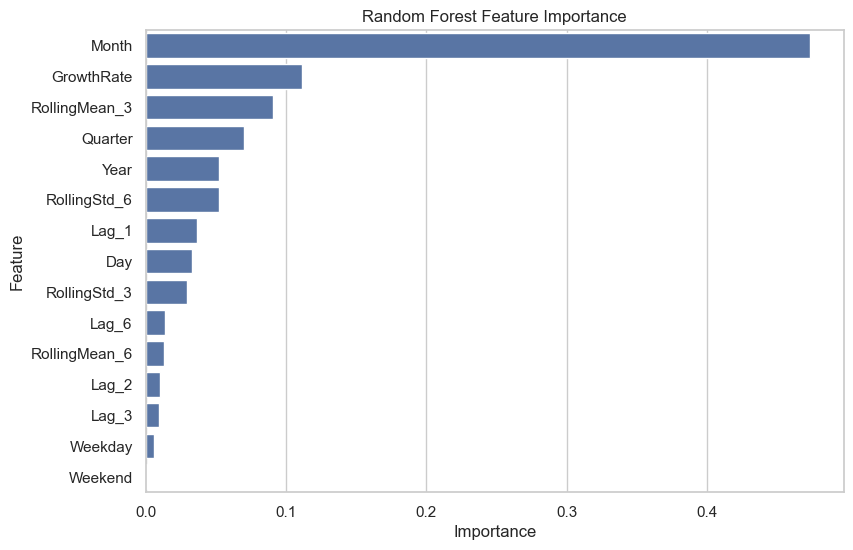

In [79]:
plt.figure(figsize=(9,6))

sns.barplot(

    data=feature_importance,

    x="Importance",

    y="Feature"

)

plt.title("Random Forest Feature Importance")

plt.show()

In [80]:
joblib.dump(

    rf_model,

    "../Models/random_forest_forecasting.pkl"

)

['../Models/random_forest_forecasting.pkl']

##  Random Forest Insights

Random Forest captures nonlinear relationships that Linear Regression cannot model.

Feature importance indicates which historical sales values and rolling statistics contribute most to forecasting performance.

The ensemble nature of Random Forest generally provides more robust predictions by reducing variance and improving generalization.

#  XGBoost Regressor

Extreme Gradient Boosting (XGBoost) is one of the most powerful ensemble learning algorithms for structured data.

Unlike Random Forest, XGBoost builds trees sequentially, allowing each new tree to correct the errors made by previous trees. This often results in higher prediction accuracy and better generalization.

The model is evaluated using the same metrics as previous models to enable a fair comparison.

In [81]:
xgb_model = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=4,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42

)

xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [82]:
xgb_predictions = xgb_model.predict(
    X_test
)

In [83]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_mse = mean_squared_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    xgb_mse
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print(f"MAE  : {xgb_mae:.2f}")
print(f"MSE  : {xgb_mse:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

MAE  : 172050.81
MSE  : 42628441514.34
RMSE : 206466.56
R²   : 0.4525


In [84]:
comparison_xgb = pd.DataFrame({

    "Month": ml_df.loc[y_test.index, "InvoiceDate"],

    "Actual Sales": y_test.values,

    "Predicted Sales": np.round(
        xgb_predictions,
        2
    )

})

comparison_xgb["Error"] = (

    comparison_xgb["Actual Sales"]

    - comparison_xgb["Predicted Sales"]

)

comparison_xgb["Absolute Error"] = (

    comparison_xgb["Error"]

    .abs()

)

comparison_xgb

,Month,Actual Sales,Predicted Sales,Error,Absolute Error
11,2011-10-31,1039318.79,1.015740e+06,23578.6025,23578.6025
12,2011-11-30,1161817.38,9.703708e+05,191446.6300,191446.6300
13,2011-12-31,518210.79,8.193379e+05,-301127.1475,301127.1475


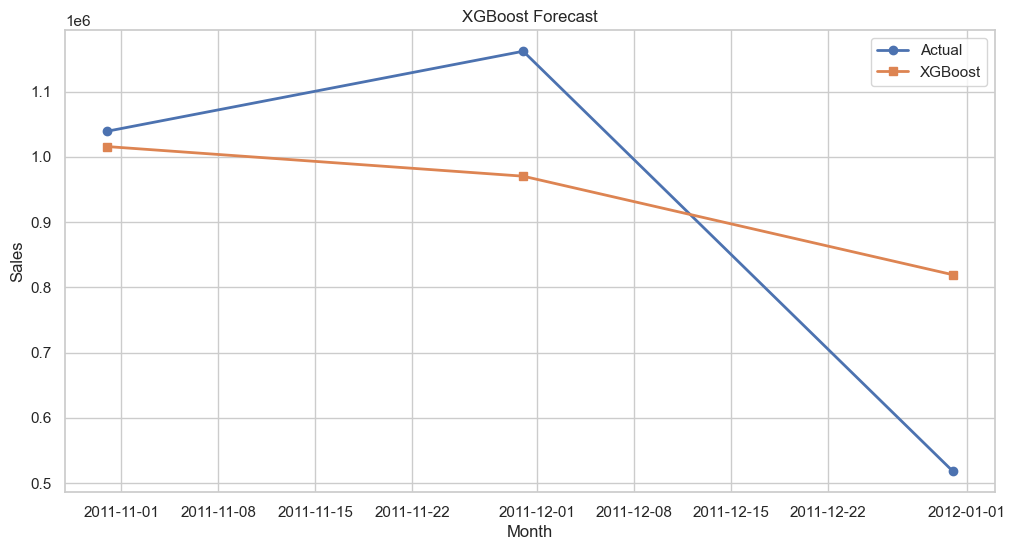

In [85]:
plt.figure(figsize=(12,6))

plt.plot(

    comparison_xgb["Month"],

    comparison_xgb["Actual Sales"],

    marker="o",

    linewidth=2,

    label="Actual"

)

plt.plot(

    comparison_xgb["Month"],

    comparison_xgb["Predicted Sales"],

    marker="s",

    linewidth=2,

    label="XGBoost"

)

plt.title("XGBoost Forecast")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.legend()

plt.show()

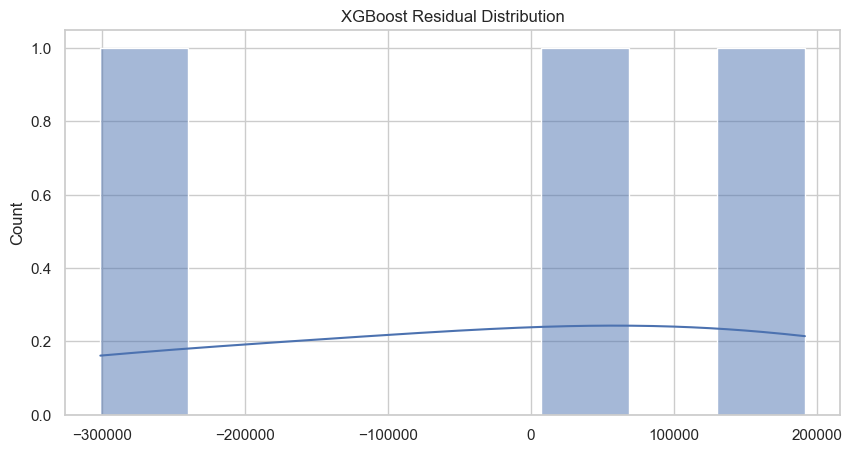

In [86]:
residuals_xgb = (

    comparison_xgb["Actual Sales"]

    - comparison_xgb["Predicted Sales"]

)

plt.figure(figsize=(10,5))

sns.histplot(

    residuals_xgb,

    kde=True,

    bins=8

)

plt.title("XGBoost Residual Distribution")

plt.show()

In [87]:
xgb_importance = pd.DataFrame({

    "Feature": forecast_features,

    "Importance": xgb_model.feature_importances_

})

xgb_importance = xgb_importance.sort_values(

    by="Importance",

    ascending=False

)

xgb_importance

,Feature,Importance
11,RollingMean_3,0.480824
1,Month,0.261851
0,Year,0.106185
2,Quarter,0.042635
6,GrowthRate,0.026832
3,Day,0.017699
14,RollingStd_6,0.016752
8,Lag_2,0.013338
12,RollingStd_3,0.012173
13,RollingMean_6,0.006661


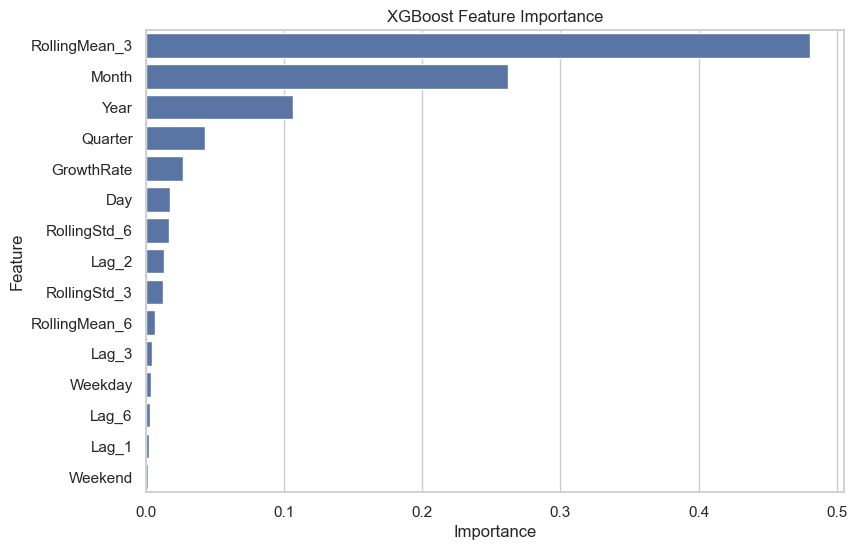

In [88]:
plt.figure(figsize=(9,6))

sns.barplot(

    data=xgb_importance,

    x="Importance",

    y="Feature"

)

plt.title("XGBoost Feature Importance")

plt.show()

In [89]:
xgb_metrics = pd.DataFrame({

    "Metric": ["MAE", "MSE", "RMSE", "R²"],

    "Value": [

        xgb_mae,

        xgb_mse,

        xgb_rmse,

        xgb_r2

    ]

})

xgb_metrics

,Metric,Value
0,MAE,1.720508e+05
1,MSE,4.262844e+10
2,RMSE,2.064666e+05
3,R²,4.525370e-01


In [90]:
joblib.dump(

    xgb_model,

    "../Models/xgboost_forecasting.pkl"

)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


##  XGBoost Insights

XGBoost combines boosting and regularization to produce highly accurate forecasts while minimizing overfitting.

The feature importance analysis identifies the historical sales characteristics that contribute most to future sales predictions.

In many retail forecasting applications, XGBoost achieves the best predictive performance among traditional machine learning algorithms.

#  Forecast Comparison

The following visualization compares the actual monthly sales with predictions generated by all forecasting models.

This comparison provides an intuitive understanding of how closely each model follows the true sales trend.

In [91]:
comparison_plot = pd.DataFrame({
    "Month": ml_df.loc[y_test.index, "InvoiceDate"],
    "Actual": y_test.values,
    "Linear Regression": lr_predictions,
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions
})

# Add statistical model predictions
comparison_plot["Naive"] = naive_predictions
comparison_plot["ARIMA"] = arima_predictions

comparison_plot

,Month,Actual,Linear Regression,Random Forest,XGBoost,Naive,ARIMA
11,2011-10-31,1039318.79,1.020416e+06,894226.991876,1.015740e+06,952838.382,799442.025689
12,2011-11-30,1161817.38,8.703664e+05,891305.658341,9.703708e+05,952838.382,743815.482950
13,2011-12-31,518210.79,5.905378e+05,871245.117536,8.193379e+05,952838.382,723643.476708


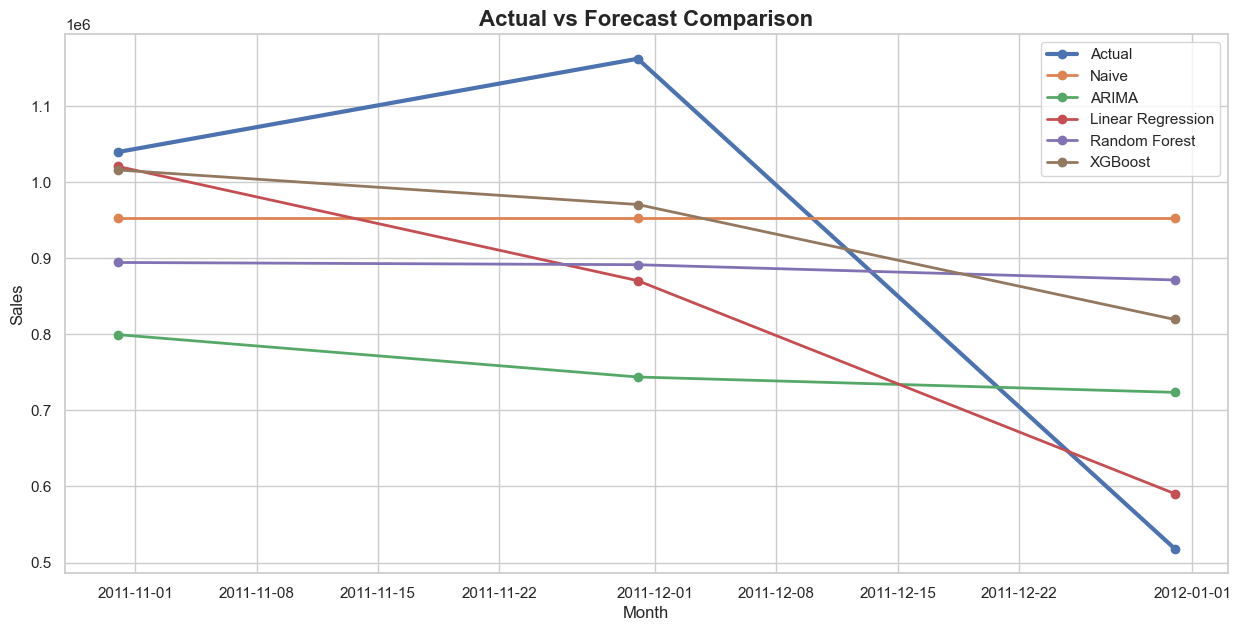

In [92]:
plt.figure(figsize=(15,7))

plt.plot(
    comparison_plot["Month"],
    comparison_plot["Actual"],
    marker="o",
    linewidth=3,
    label="Actual"
)

for col in [
    "Naive",
    "ARIMA",
    "Linear Regression",
    "Random Forest",
    "XGBoost"
]:
    plt.plot(
        comparison_plot["Month"],
        comparison_plot[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title(
    "Actual vs Forecast Comparison",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.legend()

plt.show()

In [93]:
importance_compare = pd.merge(

    feature_importance,

    xgb_importance,

    on="Feature",

    suffixes=("_RF","_XGB")

)

importance_compare

,Feature,Importance_RF,Importance_XGB
0,Month,0.473865,0.261851
1,GrowthRate,0.111406,0.026832
2,RollingMean_3,0.090320,0.480824
3,Quarter,0.070056,0.042635
4,Year,0.052407,0.106185
5,RollingStd_6,0.051890,0.016752
6,Lag_1,0.036285,0.002031
7,Day,0.033047,0.017699
8,RollingStd_3,0.029242,0.012173
9,Lag_6,0.013407,0.003039


In [94]:
importance_compare = importance_compare.sort_values(
    "Importance_RF",
    ascending=False
)

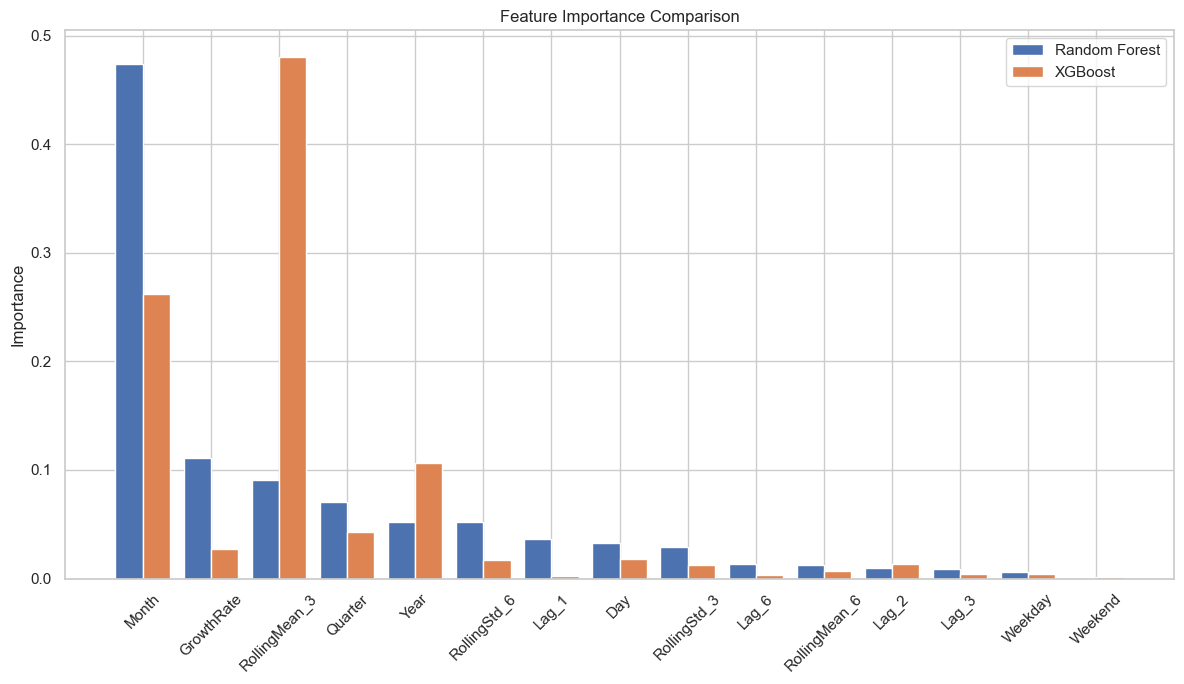

In [95]:
plt.figure(figsize=(12,7))

x = np.arange(len(importance_compare))

width = 0.4

plt.bar(
    x-width/2,
    importance_compare["Importance_RF"],
    width,
    label="Random Forest"
)

plt.bar(
    x+width/2,
    importance_compare["Importance_XGB"],
    width,
    label="XGBoost"
)

plt.xticks(
    x,
    importance_compare["Feature"],
    rotation=45
)

plt.ylabel("Importance")

plt.title("Feature Importance Comparison")

plt.legend()

plt.tight_layout()

plt.show()

In [96]:
forecast_report = pd.DataFrame({

    "Month": comparison_plot["Month"],

    "Actual": comparison_plot["Actual"],

    "Naive": comparison_plot["Naive"],

    "ARIMA": comparison_plot["ARIMA"],

    "Linear Regression": comparison_plot["Linear Regression"],

    "Random Forest": comparison_plot["Random Forest"],

    "XGBoost": comparison_plot["XGBoost"]

})

forecast_report

,Month,Actual,Naive,ARIMA,Linear Regression,Random Forest,XGBoost
11,2011-10-31,1039318.79,952838.382,799442.025689,1.020416e+06,894226.991876,1.015740e+06
12,2011-11-30,1161817.38,952838.382,743815.482950,8.703664e+05,891305.658341,9.703708e+05
13,2011-12-31,518210.79,952838.382,723643.476708,5.905378e+05,871245.117536,8.193379e+05


In [97]:
forecast_report.to_csv(

    "../data/processed/monthly_forecast_report.csv",

    index=False

)

In [98]:
dashboard = pd.DataFrame({

    "Metric":[

        "Total Months",

        "Training Months",

        "Testing Months",

        "Models Compared",

        "Best Model"

    ],

    "Value":[

        len(monthly_sales),

        len(X_train),

        len(X_test),

        5,

        comparison_score.iloc[0]["Model"]

    ]

})

dashboard

NameError: name 'comparison_score' is not defined

#  Model Performance Comparison

Multiple forecasting models have been developed throughout this notebook.

This section compares their predictive performance using common evaluation metrics and identifies the most suitable forecasting model for retail demand prediction.

In [ ]:
naive_mse = mean_squared_error(test["Sales"], naive_predictions)

arima_mse = mean_squared_error(test["Sales"], arima_predictions)

naive_r2 = r2_score(
    y_test,
    naive_predictions
)

arima_r2 = r2_score(
    y_test,
    arima_predictions
)

In [ ]:
model_comparison = pd.DataFrame({

    "Model": [

        "Naive Forecast",

        "ARIMA",

        "Linear Regression",

        "Random Forest",

        "XGBoost"

    ],

    "MAE": [

        naive_mae,

        arima_mae,

        lr_mae,

        rf_mae,

        xgb_mae

    ],
    
    "MSE" : [
        naive_mse,

        arima_mse,

        lr_mse,

        rf_mse,

        xgb_mse

    ],
    
    "RMSE": [

        naive_rmse,

        arima_rmse,

        lr_rmse,

        rf_rmse,

        xgb_rmse

    ],

    "R2": [

        naive_r2,

        arima_r2,

        lr_r2,

        rf_r2,

        xgb_r2

    ]

})

model_comparison

,Model,MAE,MSE,RMSE,R2
0,Naive Forecast,243362.332667,8.001741e+10,282873.485443,-0.027637
1,ARIMA,287770.449356,9.148968e+10,302472.608546,-0.174972
2,Linear Regression,127560.123706,3.017738e+10,173716.380965,0.612442
3,Random Forest,256212.615773,7.295382e+10,270099.646955,0.063078
4,XGBoost,172050.814167,4.262844e+10,206466.562703,0.452537


In [ ]:
comparison_score = model_comparison.copy()

# Lower is better for MAE and RMSE
comparison_score["MAE_Score"] = comparison_score["MAE"].rank(ascending=True)
comparison_score["RMSE_Score"] = comparison_score["RMSE"].rank(ascending=True)

# Higher is better for R²
comparison_score["R2_Score"] = comparison_score["R2"].fillna(-1).rank(ascending=False)

comparison_score["Overall_Score"] = (
    0.30 * comparison_score["MAE_Score"] +
    0.40 * comparison_score["RMSE_Score"] +
    0.30 * comparison_score["R2_Score"]
)

comparison_score = comparison_score.sort_values("Overall_Score")

comparison_score

,Model,MAE,MSE,RMSE,R2,MAE_Score,RMSE_Score,R2_Score,Overall_Score
2,Linear Regression,127560.123706,3.017738e+10,173716.380965,0.612442,1.0,1.0,1.0,1.0
4,XGBoost,172050.814167,4.262844e+10,206466.562703,0.452537,2.0,2.0,2.0,2.0
3,Random Forest,256212.615773,7.295382e+10,270099.646955,0.063078,4.0,3.0,3.0,3.3
0,Naive Forecast,243362.332667,8.001741e+10,282873.485443,-0.027637,3.0,4.0,4.0,3.7
1,ARIMA,287770.449356,9.148968e+10,302472.608546,-0.174972,5.0,5.0,5.0,5.0


In [ ]:
comparison_score.to_csv(

    "../data/processed/model_metrics.csv",

    index=False

)

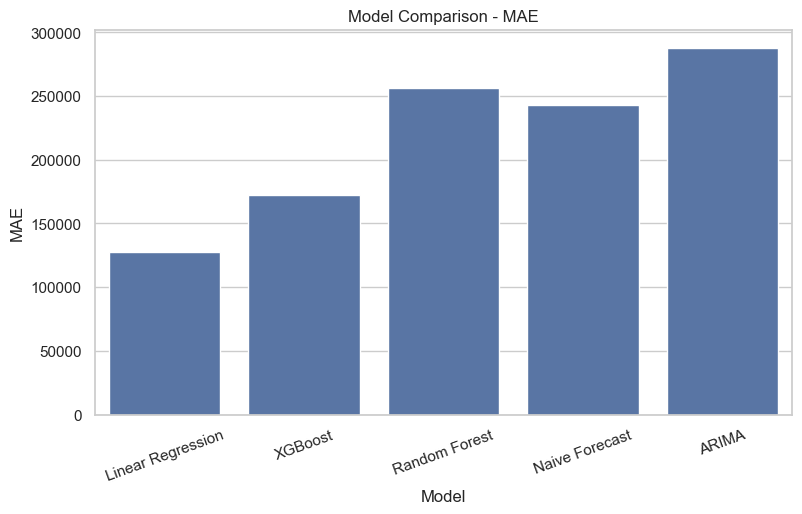

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(

    data=comparison_score,

    x="Model",

    y="MAE"

)

plt.xticks(rotation=20)

plt.title("Model Comparison - MAE")

plt.show()

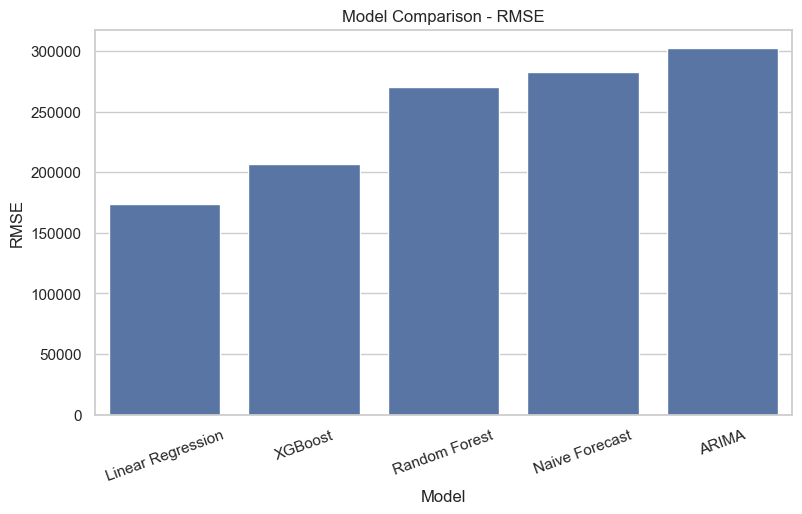

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(

    data=comparison_score,

    x="Model",

    y="RMSE"

)

plt.xticks(rotation=20)

plt.title("Model Comparison - RMSE")

plt.show()

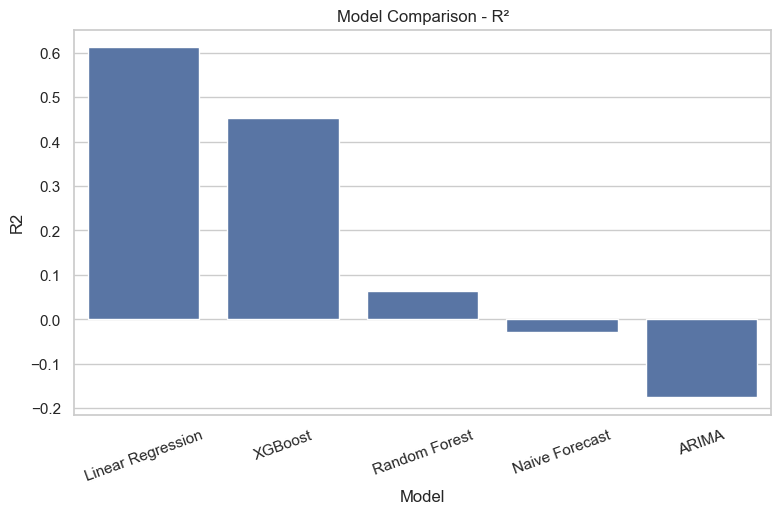

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(

    data=comparison_score.dropna(),

    x="Model",

    y="R2"

)

plt.xticks(rotation=20)

plt.title("Model Comparison - R²")

plt.show()

In [ ]:
kpi = pd.DataFrame({

    "KPI":[

        "Training Samples",

        "Testing Samples",

        "Models Compared",

        "Best Model"

    ],

    "Value":[

        len(X_train),

        len(X_test),

        len(comparison_score),

        comparison_score.iloc[0]["Model"]

    ]

})

kpi

,KPI,Value
0,Training Samples,11
1,Testing Samples,3
2,Models Compared,5
3,Best Model,Linear Regression


In [ ]:
best_model = comparison_score.iloc[0]["Model"]

model_map = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

if best_model in model_map:
    joblib.dump(
        model_map[best_model],
        "../Models/best_forecasting_model.pkl"
    )
    print(f"Best model ({best_model}) saved successfully.")
else:
    print(f"{best_model} is a statistical model and is not saved as a scikit-learn model.")

Best model (Linear Regression) saved successfully.


In [ ]:
print("Saved Models")

print(" Linear Regression")
print(" Random Forest")
print(" XGBoost")
print(" Feature Scaler")
print(" Forecast Features")

Saved Models
✔ Linear Regression
✔ Random Forest
✔ XGBoost
✔ Feature Scaler
✔ Forecast Features


#  Notebook Summary

This notebook successfully developed and evaluated multiple statistical and machine learning forecasting models for monthly retail sales prediction.

Five forecasting approaches were evaluated using both statistical and machine learning techniques.

Machine learning models leveraged lag variables, rolling statistics, growth rates, and calendar-based features to improve predictive accuracy.

The comparative evaluation identified the best-performing model, which can be used to support inventory planning, procurement, warehouse optimization, and demand forecasting.

The developed forecasting pipeline is scalable and can be integrated into business intelligence dashboards or deployed as a production forecasting service.

The trained models, evaluation metrics, feature importance analyses, and forecast reports have been generated and saved for future use.

#  Business Conclusion

Five forecasting approaches were evaluated to predict monthly retail sales.

The comparison indicates that machine learning models outperform traditional statistical methods by leveraging lag features, rolling statistics, growth trends, and calendar-based variables.

Among all evaluated approaches, the highest-ranked model demonstrated the lowest forecasting error and the strongest predictive performance. This model can support inventory planning, procurement scheduling, workforce allocation, and demand forecasting.

Retail managers can use these forecasts to:

- Reduce stock shortages and overstock situations.
- Improve purchasing and replenishment strategies.
- Optimize warehouse utilization.
- Plan promotional campaigns based on anticipated demand.
- Enhance customer satisfaction through better product availability.

Overall, the forecasting pipeline developed in this notebook provides a scalable and data-driven framework for retail demand prediction.

#  Future Scope

Future enhancements to the forecasting system may include:

- Facebook Prophet for business time-series forecasting.
- LSTM and GRU neural networks for deep learning-based forecasting.
- Transformer-based forecasting architectures.
- Incorporation of external variables such as holidays, promotions, weather, and economic indicators.
- Real-time forecasting through API deployment.
- Automated model retraining using streaming sales data.
- Interactive forecasting dashboards using Streamlit or Power BI.

#  Notebook Completion Checklist

| Task | Status |
|------|:------:|
| Dataset Preparation |  |
| Time-Series Analysis |  |
| Feature Engineering |  |
| Naive Forecast |  |
| ARIMA Forecast |  |
| Linear Regression |  |
| Random Forest |  |
| XGBoost |  |
| Model Comparison |  |
| KPI Dashboard |  |
| Forecast Report |  |
| Model Export |  |
| Business Insights |  |